PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:23:39
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/alexander.z/miniconda3/envs/gmx-plumed/lib/plumed
PLUMED: For installed feature, see /home/alexander.z/miniconda3/envs/gmx-plumed/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: 
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 1
PLUMED: File suffix: 
PLUMED: Timestep: 0.000000
PLUMED: KbT has not been set by the MD engine
PLUMED: It should be set by hand where needed
PLUMED: Relevant bibliography:
PLUMED:   [1] The PLUMED consortium, Nat. Methods 16, 670 (2019)
PLUMED:   [2] Tribello, Bonomi, Branduardi, Camilloni, and Bussi, Comput. Phys. Commun. 185, 604 (2014)
PLUMED: Please read and cite where appropriate!
PLUMED: F

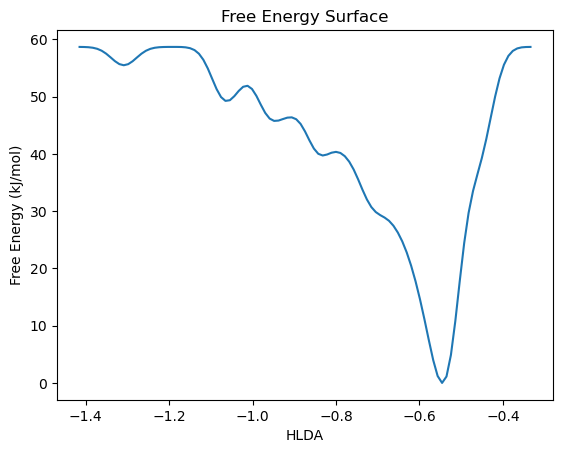

In [4]:
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from pathlib import Path
import subprocess

# Y9R, D2C
mutation = "Y9R"
index = "001"
base = Path("../data") / mutation / "output" / f"run_{index}"

subprocess.run([
    "plumed", "sum_hills",
    "--hills", base / f"HILLS_HLDA_{index}",
    "--outfile", base / "fes.dat",
    "--mintozero",
], check=True)

df = pd.read_csv(
    base / "fes.dat",
    comment="#",
    sep=r"\s+",
    names=["hlda", "free", "der_hlda"],  
    engine="python"
)


# Example plot
plt.plot(df["hlda"], df["free"])
plt.xlabel("HLDA")
plt.ylabel("Free Energy (kJ/mol)")
plt.title("Free Energy Surface")
plt.show()